Euclidean Distance is the distance formula for 2 points in a plane in infinite dimensions.
d = sqrt((x1 - x2)^2 + (y1 - y2)^2 + (z1 - z2)^2 + ...)

Imagine a plane in two dimensions where [x1, y1] = [1, 2] and [x2, y2] = [4, 6]. The distance between these two points is:
d = sqrt((1 - 4)^2 + (2 - 6)^2)
d = sqrt((-3)^2 + (-4)^2)
d = sqrt(9 + 16)
d = sqrt(25)
d = 5

Now taking this two dimensional example and applying it to higher dimensional data where we have point X, Y = [x1, x2, x3, ..., xn], [y1, y2, y3, ..., yx]
the distance formula becomes
d = sqrt((x1 - y1)^2 + (x2 - y2)^2 + (x3 - y3)^2 + ... + (xn - yn)^2)

In [44]:
import math
import random
random.seed(67)

In [45]:
def euclidean_distance(point1, point2):
  """Calculate the Euclidean distance between two points.
  
  Time Complexity: O(D) where D is the number of dimensions
  Space Complexity: O(1)
  """
  distance = 0
  for p1, p2 in zip(point1, point2):
    distance += (p1 - p2) ** 2
  return math.sqrt(distance)

In [46]:
p1, p2 = (1, 2), (4, 6)
print(euclidean_distance(p1, p2))
# The answer is 5 as expected

5.0


In a K means algorithm the steps the algorithm takes is as follows
1. Pick K random centroids (mid points) from your list of points. These start as the initial guess of where the middle value for your clusters are.
2. For each point in your dataset, calculate the euclidean distance (the standard distance formula for x and y but scaled to infinite dimensions) from your point and each centroids from step 1.
3. From your distance formula, find the closest centroid. This closest centroid is now the assignment, meaning this point belongs to a cluster with the center being the centroid.
4. Once all points have been assigned to a cluster, calculate the new midpoint of the cluster. This now becomes the new centroid.
5. Reassign the points to the nearest centroid again.
6. Repeat until convergence, the centroids no longer move.

In [47]:
# Step 1, pick a random centroid from the list of points
def pick_random_centroid(points, k):
  return random.sample(points, k)


In [48]:
# Step 2, calculate the distance of each point to each centroid
def find_closest_centroid(point, centroids):
  closest_centroid = 0
  closest_centroid_distance = euclidean_distance(point, centroids[0])
  for i in range(1, len(centroids)):
    distance = euclidean_distance(point, centroids[i])
    if distance < closest_centroid_distance:
      closest_centroid = i
      closest_centroid_distance = distance
  return closest_centroid

In [49]:
# Step 3, assign each point to the nearest centroid
def create_assignments(points, centroids):
  assignments = []
  for p in points:
    assignments.append(find_closest_centroid(p, centroids))
  return assignments

In [50]:
# Step 4, recalculate the centroids
def calculate_centroids(points, assignments, k, round_to = 6):
  # create group bins for each centroids
  clusters = [[] for _ in range(k)]

  # loop through points and assignments and add them to the centroid bins
  for point, assignment in zip(points, assignments):
    clusters[assignment].append(point)

  new_centroids = []

  for c in clusters:
    group_by_dimensions = list(zip(*c))
    new_centroid = ()
    for d in group_by_dimensions:
      new_centroid += (round(sum(d) / len(d), round_to),)
    new_centroids.append(new_centroid)
  return new_centroids

In [51]:
def run_algorithm(points, centroids, assignments, k):
  done = False
  iterations = 0
  while not done:
    iterations += 1
    new_centroid = calculate_centroids(points, assignments, k)
    new_assignments = create_assignments(points, new_centroid)
    if centroids == new_centroid:
      done = True
    else:
      centroids = new_centroid
      assignments = new_assignments
  return centroids, iterations, assignments

In [52]:
# POINTS = [(1, 1), (9, 9), (2, 2), (8,8), (0, 1), (10, 11)]
# K = 2
# random.seed(67)
# centroids = pick_random_centroid(POINTS, K)
# assignments = create_assignments(POINTS, centroids)
# centroids, iterations, assignments = run_algorithm(POINTS, centroids, assignments)
# print("Final centroid position", centroids, "\ntook a total of", iterations, "iterations\nAssignments:",assignments)

Now testing against the Iris dataset

In [53]:
def check_accuracy(assignments, labels):
    # find unique clusters
    clusters = {}
    for assignment, label in zip(assignments, labels):
        if assignment not in clusters:
            clusters[assignment] = {}
        if label not in clusters[assignment]:
            clusters[assignment][label] = 0
        clusters[assignment][label] += 1

    # find dominant species per cluster
    mapping = {}
    for cluster_id, species_counts in clusters.items():
        dominant = max(species_counts, key=lambda s: species_counts[s])
        mapping[cluster_id] = dominant

    # count correct predictions
    correct = 0
    for assignment, label in zip(assignments, labels):
        if mapping[assignment] == label:
            correct += 1

    accuracy = correct / len(labels) * 100

    # print breakdown
    for cluster_id, species_counts in clusters.items():
        print(f"cluster {cluster_id} → mapped to '{mapping[cluster_id]}' | {species_counts}")

    print(f"\ncorrect: {correct} / {len(labels)}")
    print(f"accuracy: {accuracy:.1f}%")

    return accuracy

In [54]:
import csv
import urllib.request

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
urllib.request.urlretrieve(url, "iris.csv")

points = []
labels = [] 
with open("iris.csv") as f:
    for row in csv.reader(f):
        if row:
            points.append(tuple(float(x) for x in row[:4]))
            labels.append(row[4])

K = 3
random.seed(67)
centroids = pick_random_centroid(points, K)
assignments = create_assignments(points, centroids)
centroids, iterations, assignments = run_algorithm(points, centroids, assignments, K)
accuracy = check_accuracy(assignments, labels)

cluster 0 → mapped to 'Iris-setosa' | {'Iris-setosa': 30}
cluster 1 → mapped to 'Iris-setosa' | {'Iris-setosa': 20, 'Iris-versicolor': 4}
cluster 2 → mapped to 'Iris-virginica' | {'Iris-versicolor': 46, 'Iris-virginica': 50}

correct: 100 / 150
accuracy: 66.7%


The following sections is visualizing how different initial centroids change the final clusters and accuracy of the algorithm.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random

def visualize_kmeans(points, labels, seed, run_algorithm, pick_random_centroid, create_assignments, check_accuracy, k=3):
  random.seed(seed)
  centroids = pick_random_centroid(points, k)
  assignments = create_assignments(points, centroids)
  final_centroids, iterations, final_assignments = run_algorithm(points, centroids, assignments, 3)
  accuracy = check_accuracy(final_assignments, labels)

  colors = ['#378ADD', '#1D9E75', '#D85A30']
  species = sorted(set(labels))
  species_to_int = {s: i for i, s in enumerate(species)}

  fig, axes = plt.subplots(1, 2, figsize=(14, 6))
  fig.suptitle(f"seed = {seed}  |  accuracy = {accuracy:.1f}%  |  iterations = {iterations}", fontsize=13)

  ax1 = axes[0]
  ax1.set_title("Initial centroids", fontsize=12)
  for i, point in enumerate(points):
      color = colors[species_to_int[labels[i]]]
      ax1.scatter(point[0], point[2], c=color, alpha=0.4, s=30, edgecolors='none')
  for i, c in enumerate(centroids):
      ax1.scatter(c[0], c[2], c=colors[i], s=200, marker='X', edgecolors='black', linewidths=1, zorder=5)
  ax1.set_xlabel("sepal length")
  ax1.set_ylabel("petal length")

  ax2 = axes[1]
  ax2.set_title("Final clusters", fontsize=12)
  for i, point in enumerate(points):
      color = colors[final_assignments[i]]
      ax2.scatter(point[0], point[2], c=color, alpha=0.4, s=30, edgecolors='none')
  for i, c in enumerate(final_centroids):
      ax2.scatter(c[0], c[2], c=colors[i], s=200, marker='X', edgecolors='black', linewidths=1, zorder=5)
  ax2.set_xlabel("sepal length")
  ax2.set_ylabel("petal length")

  patches = [mpatches.Patch(color=colors[i], label=species[i]) for i in range(len(species))]
  fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.02))

  plt.tight_layout()
  plt.show()
  return accuracy

cluster 1 → mapped to 'Iris-setosa' | {'Iris-setosa': 50}
cluster 2 → mapped to 'Iris-virginica' | {'Iris-versicolor': 3, 'Iris-virginica': 36}
cluster 0 → mapped to 'Iris-versicolor' | {'Iris-versicolor': 47, 'Iris-virginica': 14}

correct: 133 / 150
accuracy: 88.7%


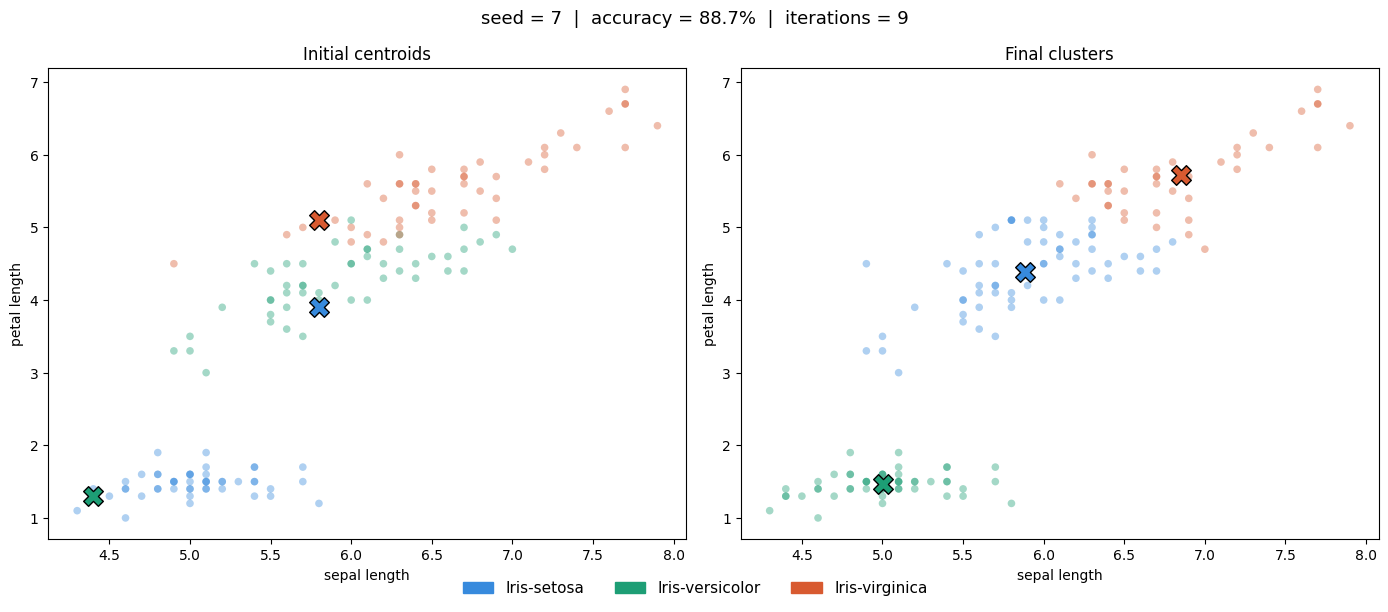

seed    7 → 88.7%
cluster 0 → mapped to 'Iris-setosa' | {'Iris-setosa': 30}
cluster 1 → mapped to 'Iris-setosa' | {'Iris-setosa': 20, 'Iris-versicolor': 4}
cluster 2 → mapped to 'Iris-virginica' | {'Iris-versicolor': 46, 'Iris-virginica': 50}

correct: 100 / 150
accuracy: 66.7%


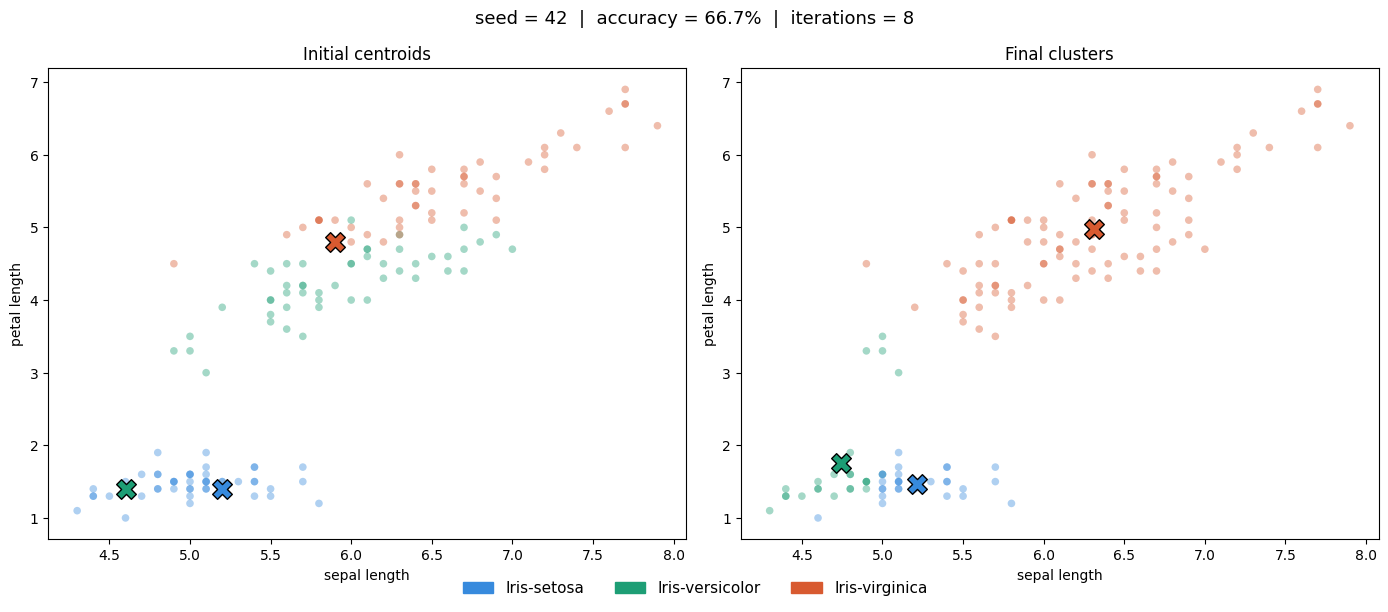

seed   42 → 66.7%
cluster 0 → mapped to 'Iris-setosa' | {'Iris-setosa': 30}
cluster 1 → mapped to 'Iris-setosa' | {'Iris-setosa': 20, 'Iris-versicolor': 4}
cluster 2 → mapped to 'Iris-virginica' | {'Iris-versicolor': 46, 'Iris-virginica': 50}

correct: 100 / 150
accuracy: 66.7%


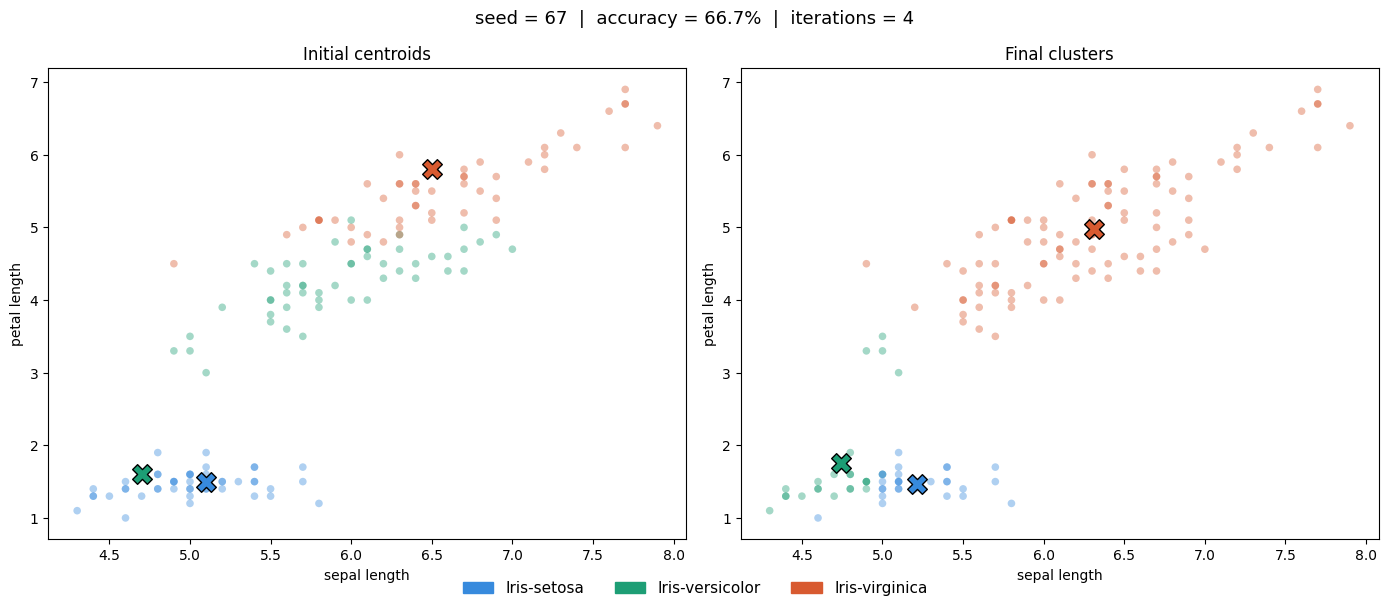

seed   67 → 66.7%
cluster 1 → mapped to 'Iris-setosa' | {'Iris-setosa': 50}
cluster 2 → mapped to 'Iris-versicolor' | {'Iris-versicolor': 48, 'Iris-virginica': 14}
cluster 0 → mapped to 'Iris-virginica' | {'Iris-versicolor': 2, 'Iris-virginica': 36}

correct: 134 / 150
accuracy: 89.3%


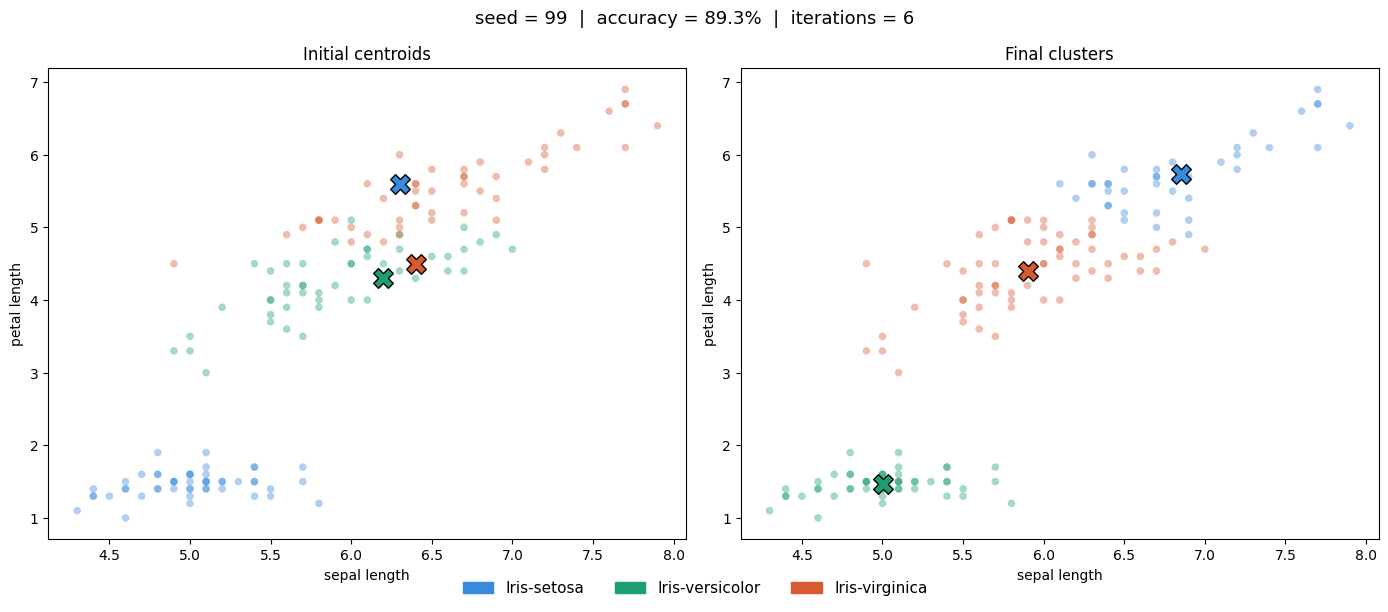

seed   99 → 89.3%
cluster 2 → mapped to 'Iris-setosa' | {'Iris-setosa': 30}
cluster 0 → mapped to 'Iris-setosa' | {'Iris-setosa': 20, 'Iris-versicolor': 4}
cluster 1 → mapped to 'Iris-virginica' | {'Iris-versicolor': 46, 'Iris-virginica': 50}

correct: 100 / 150
accuracy: 66.7%


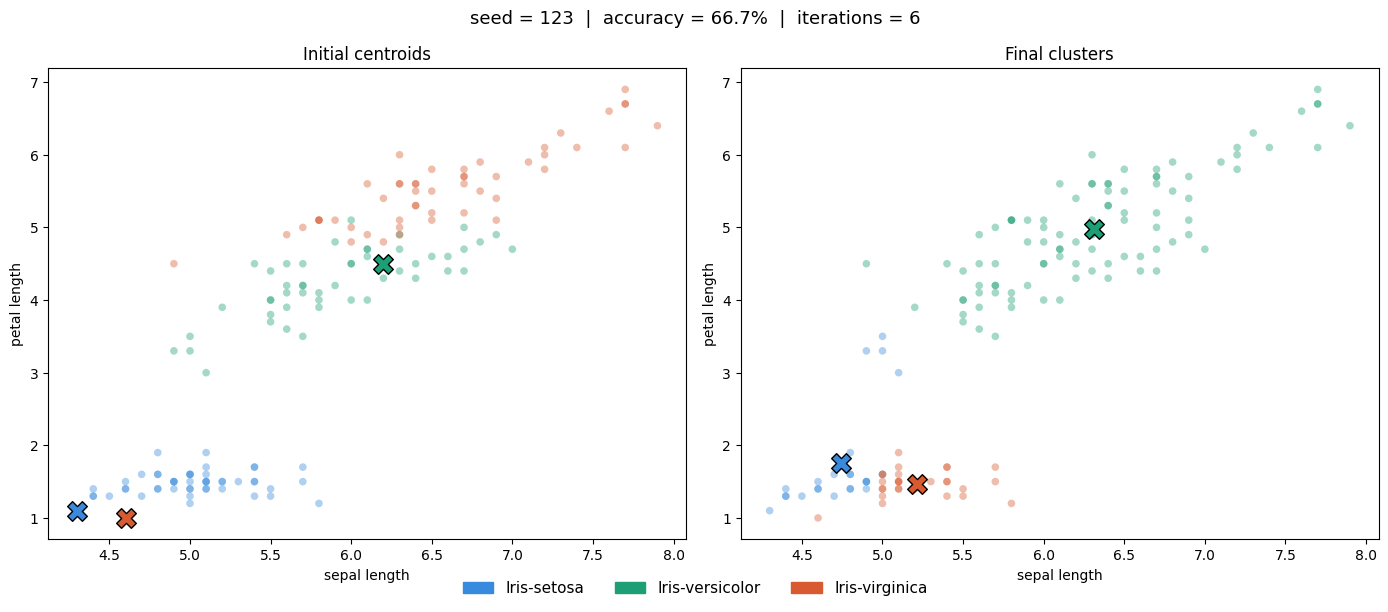

seed  123 → 66.7%


In [56]:
for seed in [7, 42, 67, 99, 123]:
    acc = visualize_kmeans(points, labels, seed=seed, run_algorithm=run_algorithm,
                           pick_random_centroid=pick_random_centroid,
                           create_assignments=create_assignments,
                           check_accuracy=check_accuracy
                           )
    print(f"seed {seed:>4} → {acc:.1f}%")